Device: cuda

── Scanning dataset ──
  REAL → 1,000 images loaded  (/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/real)
  FAKE → 1,000 images loaded  (/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/fake)

  Total : 2,000 images  (REAL: 1,000 | FAKE: 1,000)

── Loading model ──
  Model loaded successfully

── Running inference ──
  Batch 5/32
  Batch 10/32
  Batch 15/32
  Batch 20/32
  Batch 25/32
  Batch 30/32
  Batch 32/32

═══════════════════════════════════════════════════════
  RESULTS — ai-generated-images-vs-real-images (test)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

        REAL       0.67      0.94      0.78      1000
        FAKE       0.90      0.53      0.67      1000

    accuracy                           0.74      2000
   macro avg       0.78      0.74      0.72      2000
weighted avg       0.78      0.74      0.72      2000

  AUC      : 0.

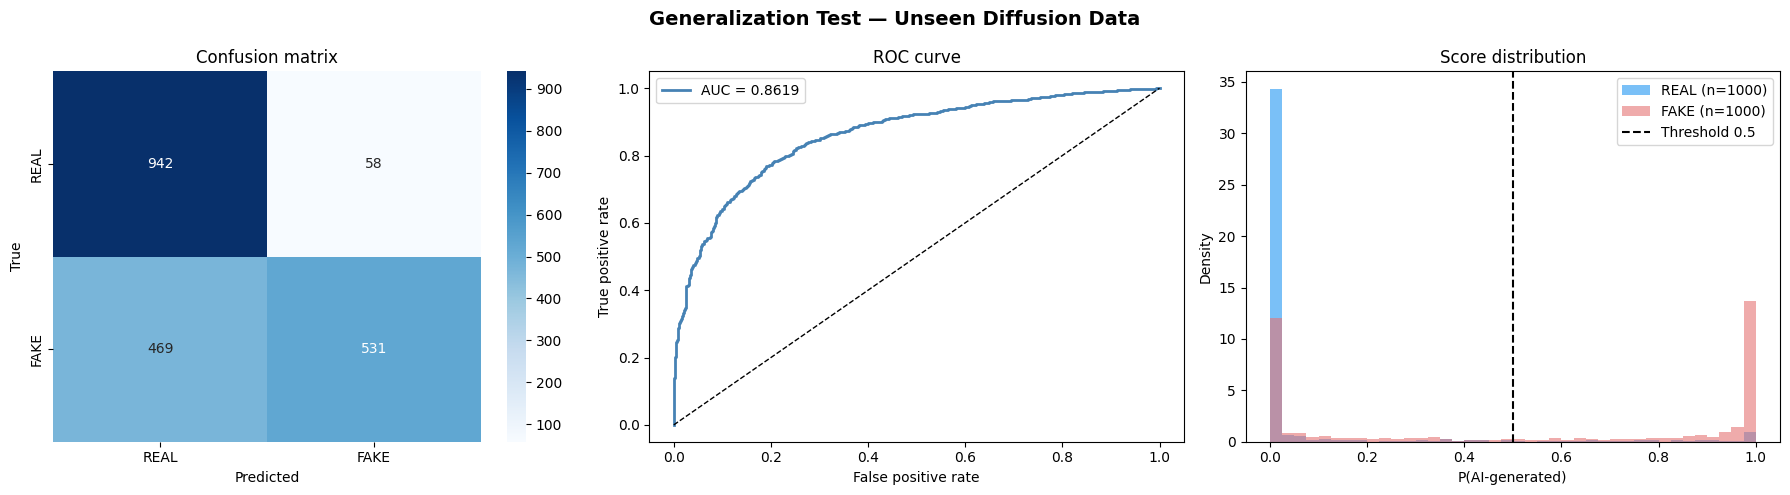


═══════════════════════════════════════════════════════
  SUMMARY
═══════════════════════════════════════════════════════
  Accuracy : 73.65%
  AUC      : 0.8619
  Images   : 2,000 (balanced: 1000 REAL / 1000 FAKE)

  Saved → /kaggle/working/generalization_results.png

── How to interpret ──
  AUC > 0.90  → No overfitting — excellent generalization
  AUC 0.80-0.90 → Good generalization — valid for PFE
  AUC 0.70-0.80 → Mild generalization gap — mention as limitation
  AUC < 0.70  → Significant gap — model may be overfit to training generators



In [1]:
# ============================================================
#  Generalization Test — ai-generated-images-vs-real-images
#  Model  : your trained ViT-B/16
#  Data   : test/real + test/fake (500 each = 1000 total)
#  Goal   : check if model generalizes to unseen diffusion data
# ============================================================
# HOW TO USE ON KAGGLE:
#   1. Add dataset: search "tristanzhang32/ai-generated-images-vs-real-images"
#   2. Your model is already mounted as "test model"
#   3. Enable GPU T4 in Settings → Accelerator
#   4. Run this single cell
# ============================================================

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, roc_curve)
import seaborn as sns
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import timm

# ── reproducibility ──────────────────────────────────────────
random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── paths ─────────────────────────────────────────────────────
MODEL_PATH   = "/kaggle/input/datasets/mentouzabdu/test-model-3/best_vit_fake_detector_v3.pt"
DATA_ROOT    = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images"
SAMPLES_EACH = 1000   # 500 real + 500 fake = 1000 total

IMG_SIZE   = 224
BATCH_SIZE = 64

# ── transforms (identical to training) ───────────────────────
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

# ── collect images ────────────────────────────────────────────
print("\n── Scanning dataset ──")
all_samples = []   # (path, label, class_name)
                   # REAL=0, FAKE=1

for label, folder in enumerate(["real", "fake"]):
    folder_path = os.path.join(DATA_ROOT, "test", folder)

    if not os.path.isdir(folder_path):
        # some datasets use capital letters
        folder_path = os.path.join(DATA_ROOT, "test", folder.upper())

    if not os.path.isdir(folder_path):
        print(f"  [ERROR] folder not found: {folder_path}")
        print(f"  Available folders: {os.listdir(os.path.join(DATA_ROOT, 'test'))}")
        continue

    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]
    random.shuffle(files)
    files = files[:SAMPLES_EACH]

    for fname in files:
        all_samples.append(
            (os.path.join(folder_path, fname), label, folder)
        )
    print(f"  {folder.upper():4s} → {len(files):,} images loaded  ({folder_path})")

random.shuffle(all_samples)
real_n = sum(1 for _, l, _ in all_samples if l == 0)
fake_n = sum(1 for _, l, _ in all_samples if l == 1)
print(f"\n  Total : {len(all_samples):,} images  "
      f"(REAL: {real_n:,} | FAKE: {fake_n:,})")

# ── dataset ───────────────────────────────────────────────────
class ImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label, cls = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label, cls

def collate_fn(batch):
    imgs   = torch.stack([b[0] for b in batch])
    labels = torch.tensor([b[1] for b in batch])
    cls    = [b[2] for b in batch]
    return imgs, labels, cls

dataset = ImageDataset(all_samples, transform=val_tf)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=2, pin_memory=True, collate_fn=collate_fn)

# ── load model ────────────────────────────────────────────────
print("\n── Loading model ──")
model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()
print("  Model loaded successfully")

# ── inference ─────────────────────────────────────────────────
print("\n── Running inference ──")
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for i, (imgs, labels, _) in enumerate(loader):
        imgs  = imgs.to(device)
        out   = model(imgs)
        probs = torch.softmax(out, dim=1)[:, 1]
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        if (i + 1) % 5 == 0 or (i + 1) == len(loader):
            print(f"  Batch {i+1}/{len(loader)}")

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── results ───────────────────────────────────────────────────
print("\n" + "═"*55)
print("  RESULTS — ai-generated-images-vs-real-images (test)")
print("═"*55)
print(classification_report(all_labels, all_preds,
                             target_names=["REAL", "FAKE"]))
overall_auc = roc_auc_score(all_labels, all_probs)
overall_acc = (all_preds == all_labels).mean()
print(f"  AUC      : {overall_auc:.4f}")
print(f"  Accuracy : {overall_acc*100:.2f}%")

# ── plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Generalization Test — Unseen Diffusion Data",
             fontsize=14, fontweight="bold")

# 1. confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", ax=axes[0],
            xticklabels=["REAL", "FAKE"],
            yticklabels=["REAL", "FAKE"], cmap="Blues")
axes[0].set_title("Confusion matrix")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

# 2. ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"AUC = {overall_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()

# 3. score distribution
axes[2].hist(all_probs[all_labels==0], bins=40, alpha=0.6,
             color="#2196F3", label=f"REAL (n={real_n})", density=True)
axes[2].hist(all_probs[all_labels==1], bins=40, alpha=0.6,
             color="#E57373", label=f"FAKE (n={fake_n})", density=True)
axes[2].axvline(x=0.5, color="black", linestyle="--",
                lw=1.5, label="Threshold 0.5")
axes[2].set_xlabel("P(AI-generated)")
axes[2].set_ylabel("Density")
axes[2].set_title("Score distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/generalization_results.png", dpi=130)
plt.show()

# ── summary ───────────────────────────────────────────────────
print("\n" + "═"*55)
print("  SUMMARY")
print("═"*55)
print(f"  Accuracy : {overall_acc*100:.2f}%")
print(f"  AUC      : {overall_auc:.4f}")
print(f"  Images   : {len(all_labels):,} (balanced: {real_n} REAL / {fake_n} FAKE)")
print(f"\n  Saved → /kaggle/working/generalization_results.png")

print("""
── How to interpret ──
  AUC > 0.90  → No overfitting — excellent generalization
  AUC 0.80-0.90 → Good generalization — valid for PFE
  AUC 0.70-0.80 → Mild generalization gap — mention as limitation
  AUC < 0.70  → Significant gap — model may be overfit to training generators
""")